In [1]:
import pandas as pd

df_label = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/humanlung/A37/WSA_LngSP9258464/MoranR_Cell2location.csv", index_col=0)
df_label

,A,B,R_val,R_z_score,R_p_val
375,B_plasma_IgA,SMG_Duct,0.534362,170.730001,0.0
3116,SMG_Duct,SMG_Serous,0.527788,168.629791,0.0
2999,Myoepithelial,SMG_Serous,0.519423,165.956914,0.0
377,B_plasma_IgA,SMG_Serous,0.517036,165.194274,0.0
769,CD4_naive_CM,Fibro_myofibroblast,0.464998,148.568066,0.0
...,...,...,...,...,...
528,B_plasmablast,Secretory_Goblet,-0.136531,-43.622171,1.0
2706,Mast_cell,Myoepithelial,-0.145356,-46.441521,1.0
354,B_plasma_IgA,Mast_cell,-0.168560,-53.855495,1.0
2715,Mast_cell,SMG_Duct,-0.175645,-56.119031,1.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns


df_figure = df_label[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
    
correlation_df['gdT'].gdT = 1.0
correlation_df

,AT1,AT2,B_memory,B_naive,B_plasma_IgA,B_plasma_IgG,B_plasmablast,Basal,CD4_EM_Effector,CD4_TRM,...,SMG_Duct,SMG_Mucous,SMG_Serous,Schwann_Myelinating,Schwann_nonmyelinating,Secretory_Club,Secretory_Goblet,Suprabasal,T_reg,gdT
AT1,1.000000,0.108918,0.012894,0.061589,-0.075173,-0.053145,-0.066985,0.094973,0.068606,0.049974,...,-0.061820,-0.018185,-0.058177,-0.016258,0.036703,0.053192,0.035961,0.075923,0.082546,0.028183
AT2,0.108918,1.000000,0.012538,0.049429,-0.025764,-0.044808,-0.022870,0.061242,0.056149,0.045209,...,-0.007401,0.002808,-0.018777,0.001266,0.015091,0.040103,0.004579,0.044029,0.061843,0.041552
B_memory,0.012894,0.012538,1.000000,0.104682,-0.014712,0.127547,0.118746,0.015730,0.126249,0.125041,...,-0.020613,-0.031819,-0.037754,-0.010819,0.055513,0.012294,-0.002762,0.019817,0.102113,0.133617
B_naive,0.061589,0.049429,0.104682,1.000000,0.073337,0.032873,0.089977,0.199703,0.364154,0.359042,...,0.107180,0.106027,0.068239,0.100444,0.063843,0.300047,0.238930,0.209035,0.358918,0.301994
B_plasma_IgA,-0.075173,-0.025764,-0.014712,0.073337,1.000000,0.082797,0.379915,-0.103158,0.134546,0.185138,...,0.534362,0.255344,0.517036,0.362561,-0.008583,0.093659,-0.106729,-0.112929,0.056306,0.326758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Secretory_Club,0.053192,0.040103,0.012294,0.300047,0.093659,-0.078285,0.001351,0.209818,0.307394,0.302185,...,0.142773,0.147446,0.118132,0.128548,0.026339,1.000000,0.264339,0.219710,0.320646,0.232879
Secretory_Goblet,0.035961,0.004579,-0.002762,0.238930,-0.106729,-0.052863,-0.136531,0.210945,0.212014,0.194429,...,-0.086225,0.055859,-0.106591,-0.027501,0.017672,0.264339,1.000000,0.237086,0.260338,0.053582
Suprabasal,0.075923,0.044029,0.019817,0.209035,-0.112929,-0.071937,-0.127952,0.269454,0.183215,0.162687,...,-0.091221,0.011660,-0.103147,-0.036072,0.013092,0.219710,0.237086,1.000000,0.226625,0.057628
T_reg,0.082546,0.061843,0.102113,0.358918,0.056306,0.014229,0.069623,0.216303,0.395160,0.384452,...,0.095928,0.109304,0.059528,0.111112,0.090307,0.320646,0.260338,0.226625,1.000000,0.321954


In [7]:
from sklearn.preprocessing import StandardScaler
import copy

# Create an instance of StandardScaler
scaler = StandardScaler()

# Normalize the DataFrame
normalized_df = copy.deepcopy(correlation_df)
normalized_df[normalized_df < 0.3] = 0.0
normalized_df

,AT1,AT2,B_memory,B_naive,B_plasma_IgA,B_plasma_IgG,B_plasmablast,Basal,CD4_EM_Effector,CD4_TRM,...,SMG_Duct,SMG_Mucous,SMG_Serous,Schwann_Myelinating,Schwann_nonmyelinating,Secretory_Club,Secretory_Goblet,Suprabasal,T_reg,gdT
AT1,1.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
AT2,0.0,1.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
B_memory,0.0,0.0,1.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
B_naive,0.0,0.0,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.364154,0.359042,...,0.000000,0.0,0.000000,0.000000,0.0,0.300047,0.0,0.0,0.358918,0.301994
B_plasma_IgA,0.0,0.0,0.0,0.000000,1.000000,0.0,0.379915,0.0,0.000000,0.000000,...,0.534362,0.0,0.517036,0.362561,0.0,0.000000,0.0,0.0,0.000000,0.326758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Secretory_Club,0.0,0.0,0.0,0.300047,0.000000,0.0,0.000000,0.0,0.307394,0.302185,...,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.0,0.0,0.320646,0.000000
Secretory_Goblet,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,1.0,0.0,0.000000,0.000000
Suprabasal,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,1.0,0.000000,0.000000
T_reg,0.0,0.0,0.0,0.358918,0.000000,0.0,0.000000,0.0,0.395160,0.384452,...,0.000000,0.0,0.000000,0.000000,0.0,0.320646,0.0,0.0,1.000000,0.321954


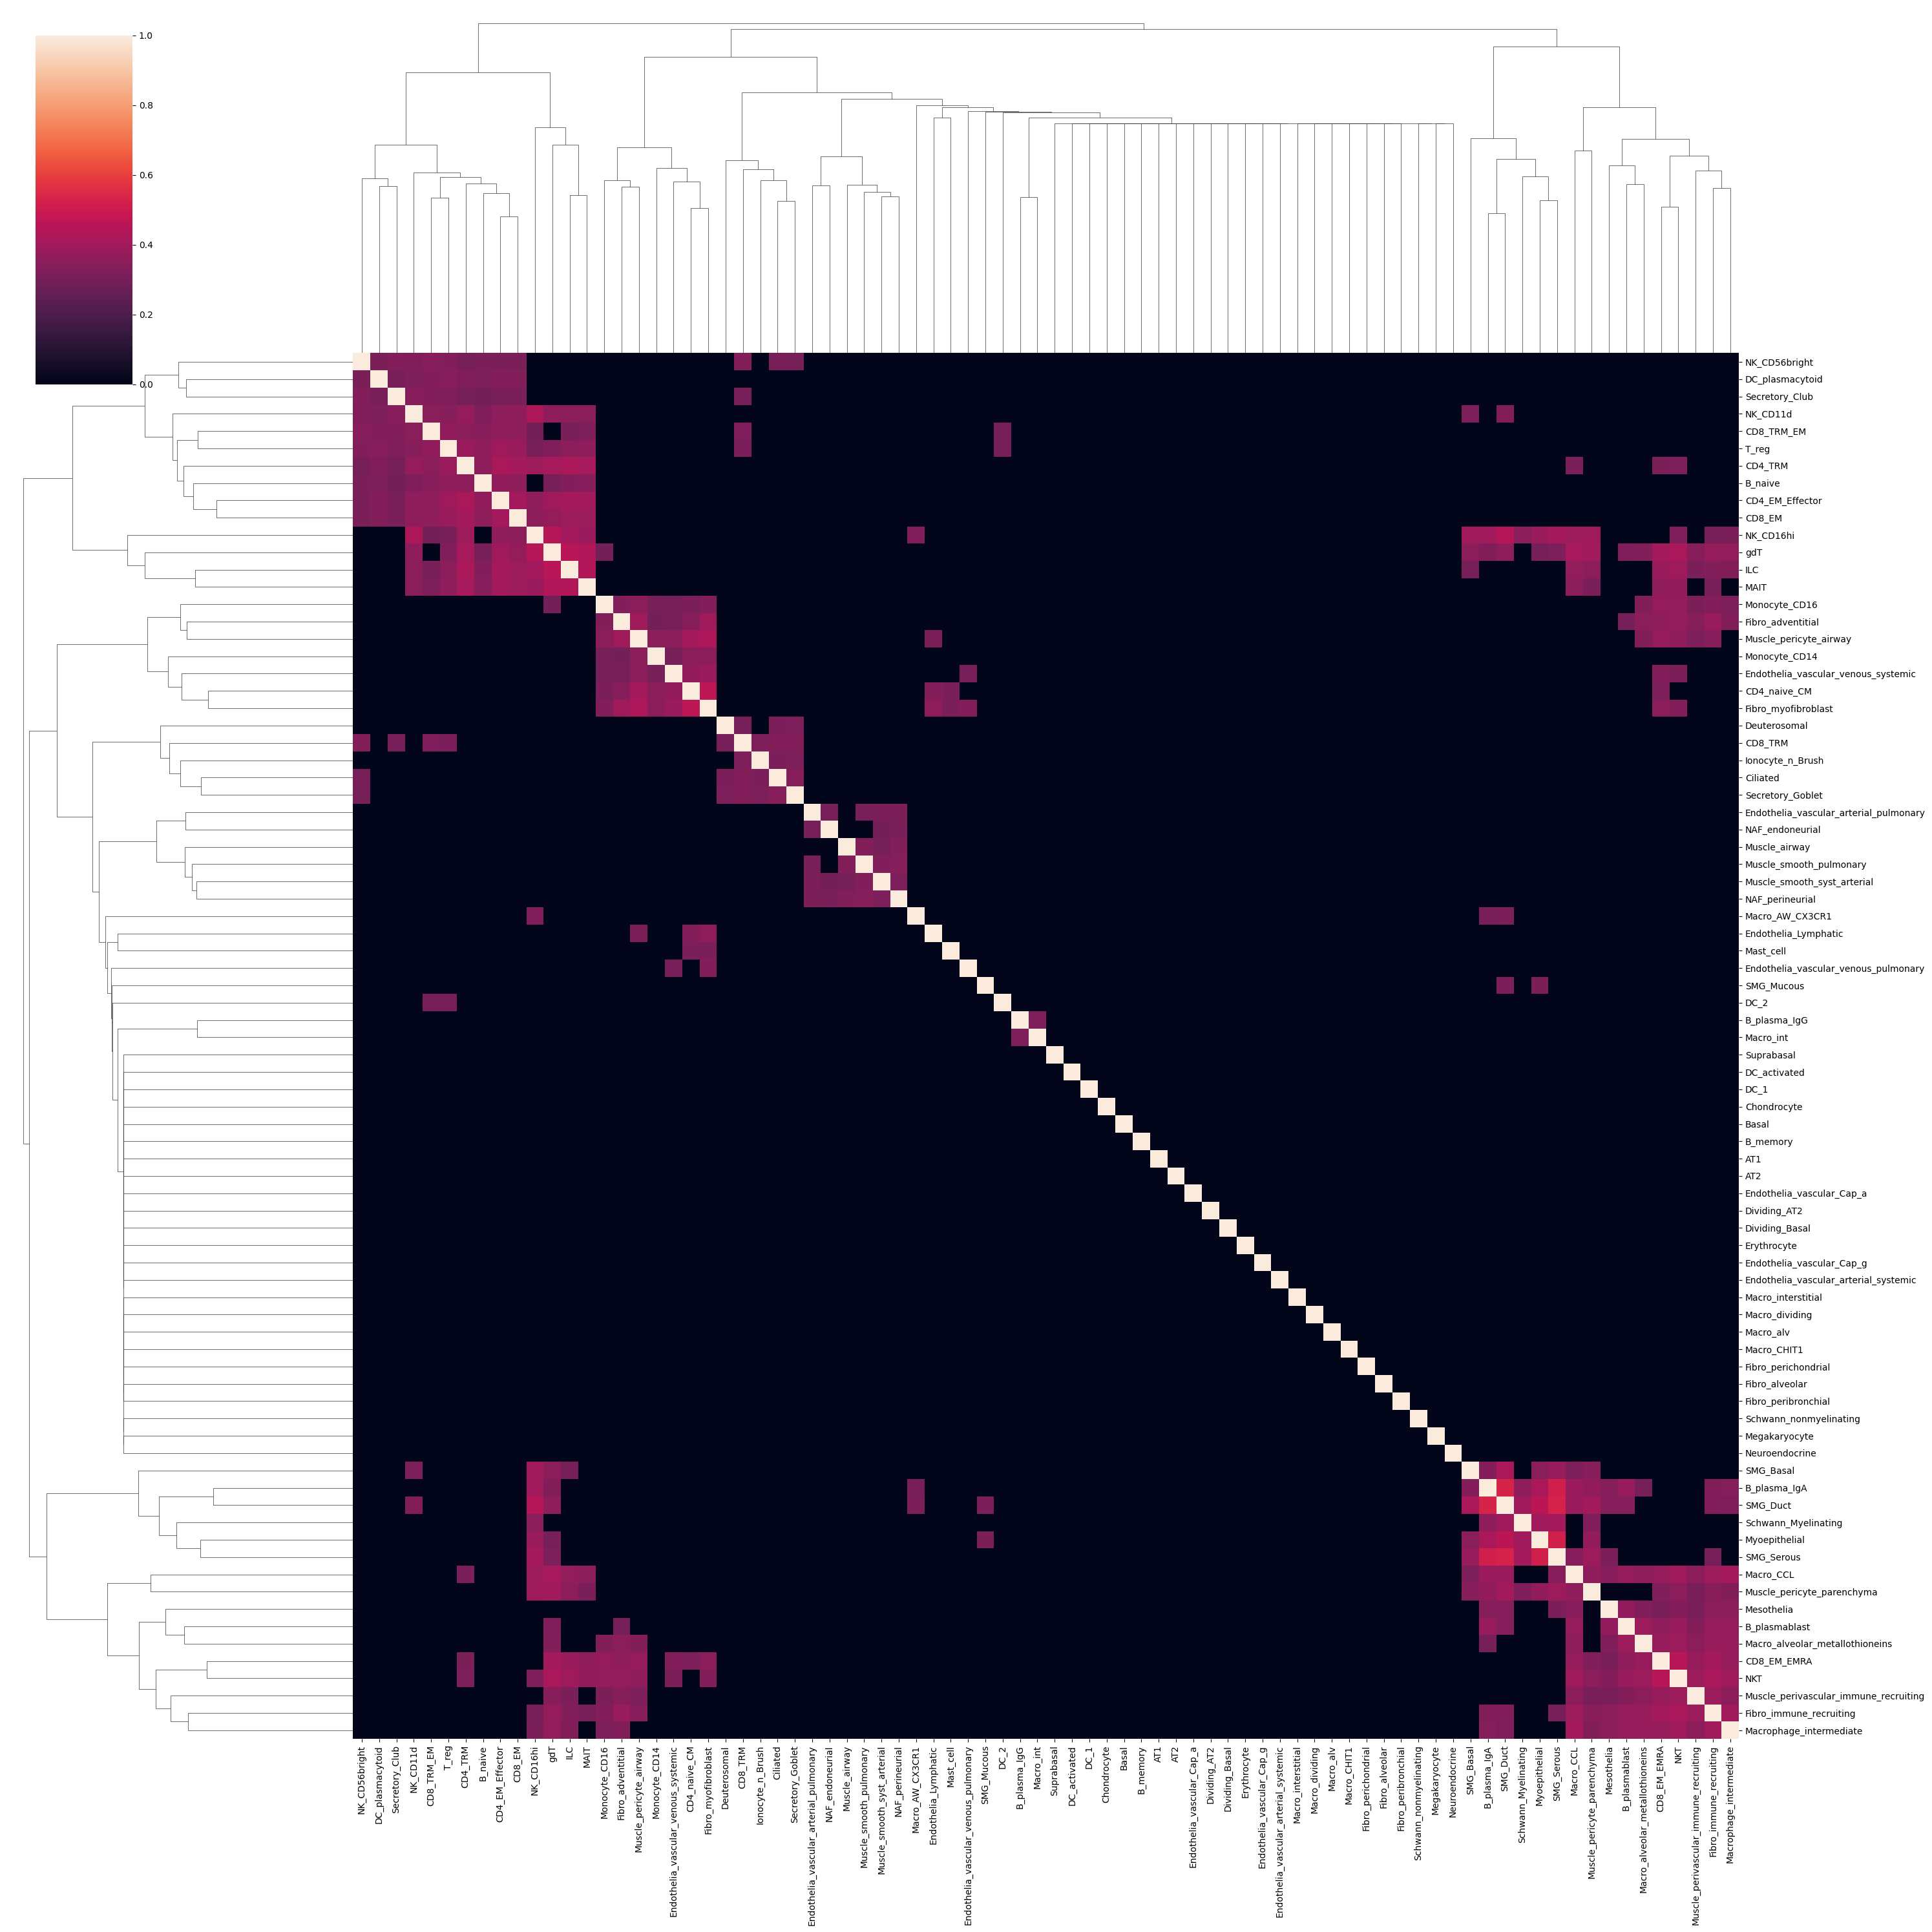

In [8]:
# sns.clustermap(correlation_df, figsize=(60, 60))
cell2location_cluster = sns.clustermap(normalized_df, figsize=(30, 30))

In [41]:
dir(cell2location_cluster)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_figure',
 '_get_palette',
 '_legend_out',
 '_margin_titles',
 '_preprocess_colors',
 '_update_legend_data',
 'add_legend',
 'apply',
 'ax_cbar',
 'ax_col_colors',
 'ax_col_dendrogram',
 'ax_heatmap',
 'ax_row_colors',
 'ax_row_dendrogram',
 'cax',
 'cbar_pos',
 'col_color_labels',
 'col_colors',
 'color_list_to_matrix_and_cmap',
 'data',
 'data2d',
 'dendrogram_col',
 'dendrogram_row',
 'dim_ratios',
 'fig',
 'figure',
 'format_data',
 'gs',
 'legend',
 'mask',
 'pipe',
 'plot',
 'plot_colors',
 'plot_dendrograms',
 'plot_matrix',
 'row_color_labels',
 'row_colors',
 'savefig',
 'set',
 'standard_scale'

In [39]:
row_order = cell2location_cluster.dendrogram_row.reordered_ind
column_order = cell2location_cluster.dendrogram_col.reordered_ind
column_order

[50,
 43,
 5,
 47,
 54,
 32,
 56,
 29,
 24,
 53,
 30,
 10,
 35,
 44,
 2,
 46,
 48,
 17,
 65,
 66,
 11,
 8,
 9,
 40,
 38,
 79,
 42,
 57,
 52,
 12,
 64,
 58,
 34,
 49,
 6,
 45,
 71,
 41,
 69,
 73,
 61,
 72,
 4,
 70,
 31,
 15,
 37,
 3,
 78,
 14,
 20,
 18,
 51,
 67,
 75,
 19,
 13,
 21,
 39,
 16,
 76,
 23,
 7,
 77,
 68,
 74,
 28,
 60,
 55,
 59,
 63,
 26,
 25,
 27,
 62,
 22,
 36,
 1,
 0,
 33]

In [81]:
df_label = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/humanlung/A37/WSA_LngSP9258464/MoranR_Hist2Cell.csv", index_col=0)
df_label

,A,B,R_val,R_z_score,R_p_val
310,B_plasma_IgA,B_plasma_IgG,0.579401,185.120043,0.0
2339,ILC,gdT,0.531078,169.680788,0.0
674,CD4_EM_Effector,gdT,0.529216,169.086038,0.0
450,B_plasma_IgG,SMG_Mucous,0.527969,168.687409,0.0
376,B_plasma_IgA,SMG_Mucous,0.526611,168.253534,0.0
...,...,...,...,...,...
1114,Chondrocyte,Megakaryocyte,-0.127110,-40.611980,1.0
1088,Chondrocyte,Endothelia_Lymphatic,-0.135610,-43.327912,1.0
680,CD4_TRM,Chondrocyte,-0.137850,-44.043554,1.0
394,B_plasma_IgG,Chondrocyte,-0.160272,-51.207400,1.0


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns


df_figure = df_label[['A', 'B', 'R_val']]
correlation_df = df_figure.pivot(index="A", columns="B", values="R_val")
for var in correlation_df.index:
    correlation_df.at[var, var] = 1
    correlation_df = correlation_df.combine_first(correlation_df.T)
    
correlation_df['gdT'].gdT = 1.0
correlation_df

,AT1,AT2,B_memory,B_naive,B_plasma_IgA,B_plasma_IgG,B_plasmablast,Basal,CD4_EM_Effector,CD4_TRM,...,SMG_Duct,SMG_Mucous,SMG_Serous,Schwann_Myelinating,Schwann_nonmyelinating,Secretory_Club,Secretory_Goblet,Suprabasal,T_reg,gdT
AT1,1.000000,0.248312,0.297627,0.326568,0.258418,0.275094,0.264378,0.190964,0.331251,0.311834,...,0.233773,0.266660,0.232264,0.274500,0.182595,0.218525,0.207317,0.200177,0.324213,0.332229
AT2,0.248312,1.000000,0.239342,0.272942,0.262731,0.272162,0.219964,0.143039,0.250000,0.245811,...,0.161715,0.236673,0.214561,0.175630,0.060720,0.148150,0.160253,0.150676,0.262317,0.257645
B_memory,0.297627,0.239342,1.000000,0.414748,0.362750,0.398495,0.434360,0.218633,0.463092,0.437702,...,0.395467,0.375966,0.352028,0.427763,0.297433,0.325700,0.251769,0.226843,0.433425,0.471743
B_naive,0.326568,0.272942,0.414748,1.000000,0.427142,0.451763,0.394488,0.349685,0.496252,0.490439,...,0.387292,0.464903,0.374994,0.427542,0.264081,0.382768,0.376901,0.364167,0.493468,0.484842
B_plasma_IgA,0.258418,0.262731,0.362750,0.427142,1.000000,0.579401,0.457451,0.213712,0.417384,0.433390,...,0.437138,0.526611,0.517038,0.443425,0.160963,0.305588,0.236134,0.218688,0.412843,0.456754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Secretory_Club,0.218525,0.148150,0.325700,0.382768,0.305588,0.319966,0.314135,0.299403,0.400076,0.402651,...,0.374004,0.375434,0.308289,0.377811,0.234902,1.000000,0.305722,0.296655,0.389875,0.390390
Secretory_Goblet,0.207317,0.160253,0.251769,0.376901,0.236134,0.302848,0.197659,0.373069,0.355812,0.358768,...,0.207198,0.334095,0.191470,0.262689,0.210998,0.305722,1.000000,0.393777,0.368748,0.297495
Suprabasal,0.200177,0.150676,0.226843,0.364167,0.218688,0.283979,0.175429,0.389813,0.336668,0.339137,...,0.183543,0.319295,0.170079,0.240317,0.192975,0.296655,0.393777,1.000000,0.352939,0.274348
T_reg,0.324213,0.262317,0.433425,0.493468,0.412843,0.447524,0.411285,0.339483,0.509273,0.495787,...,0.407786,0.458873,0.377389,0.449019,0.298859,0.389875,0.368748,0.352939,1.000000,0.495455


In [83]:
correlation_df.describe()

,AT1,AT2,B_memory,B_naive,B_plasma_IgA,B_plasma_IgG,B_plasmablast,Basal,CD4_EM_Effector,CD4_TRM,...,SMG_Duct,SMG_Mucous,SMG_Serous,Schwann_Myelinating,Schwann_nonmyelinating,Secretory_Club,Secretory_Goblet,Suprabasal,T_reg,gdT
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,...,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,0.248404,0.193344,0.344496,0.357537,0.318490,0.341548,0.350565,0.222494,0.390872,0.368254,...,0.334545,0.340147,0.303288,0.368306,0.263683,0.285893,0.245855,0.232731,0.367936,0.390185
std,0.114907,0.124708,0.127376,0.138346,0.150866,0.142435,0.136270,0.139674,0.131852,0.138461,...,0.142685,0.145543,0.141244,0.138946,0.135599,0.130822,0.139095,0.140979,0.133903,0.136041
min,-0.043289,-0.031786,-0.164842,-0.075462,-0.070098,-0.160272,-0.090126,-0.061116,-0.115493,-0.137850,...,-0.095787,-0.100996,-0.069556,-0.110221,-0.122534,-0.111984,-0.094282,-0.067263,-0.107203,-0.089958
25%,0.199928,0.136679,0.291543,0.274438,0.231557,0.271158,0.279452,0.134450,0.336449,0.299454,...,0.255582,0.235058,0.213381,0.298866,0.197659,0.225265,0.165092,0.145367,0.305587,0.322206
50%,0.254652,0.206525,0.360930,0.376264,0.329710,0.342655,0.369417,0.213082,0.402172,0.376040,...,0.353175,0.348346,0.305963,0.386148,0.274675,0.303329,0.235261,0.219233,0.378833,0.409576
75%,0.305306,0.260223,0.411141,0.439495,0.418005,0.430011,0.435369,0.308725,0.462098,0.453120,...,0.422355,0.440566,0.395651,0.449890,0.323728,0.367254,0.327343,0.318914,0.447898,0.479394
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [84]:
# Get the row and column linkage from the first clustermap
row_linkage = cell2location_cluster.dendrogram_row.linkage
col_linkage = cell2location_cluster.dendrogram_col.linkage

In [89]:
from sklearn.preprocessing import StandardScaler
import copy

# Create an instance of StandardScaler
scaler = StandardScaler()

# Normalize the DataFrame
normalized_df = copy.deepcopy(correlation_df)
normalized_df[normalized_df < 0.4] = 0.0
normalized_df

,AT1,AT2,B_memory,B_naive,B_plasma_IgA,B_plasma_IgG,B_plasmablast,Basal,CD4_EM_Effector,CD4_TRM,...,SMG_Duct,SMG_Mucous,SMG_Serous,Schwann_Myelinating,Schwann_nonmyelinating,Secretory_Club,Secretory_Goblet,Suprabasal,T_reg,gdT
AT1,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
AT2,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
B_memory,0.0,0.0,1.000000,0.414748,0.000000,0.000000,0.434360,0.0,0.463092,0.437702,...,0.000000,0.000000,0.000000,0.427763,0.0,0.0,0.0,0.0,0.433425,0.471743
B_naive,0.0,0.0,0.414748,1.000000,0.427142,0.451763,0.000000,0.0,0.496252,0.490439,...,0.000000,0.464903,0.000000,0.427542,0.0,0.0,0.0,0.0,0.493468,0.484842
B_plasma_IgA,0.0,0.0,0.000000,0.427142,1.000000,0.579401,0.457451,0.0,0.417384,0.433390,...,0.437138,0.526611,0.517038,0.443425,0.0,0.0,0.0,0.0,0.412843,0.456754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Secretory_Club,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.400076,0.402651,...,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,0.000000,0.000000
Secretory_Goblet,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,0.000000,0.000000
Suprabasal,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,0.000000,0.000000
T_reg,0.0,0.0,0.433425,0.493468,0.412843,0.447524,0.411285,0.0,0.509273,0.495787,...,0.407786,0.458873,0.000000,0.449019,0.0,0.0,0.0,0.0,1.000000,0.495455


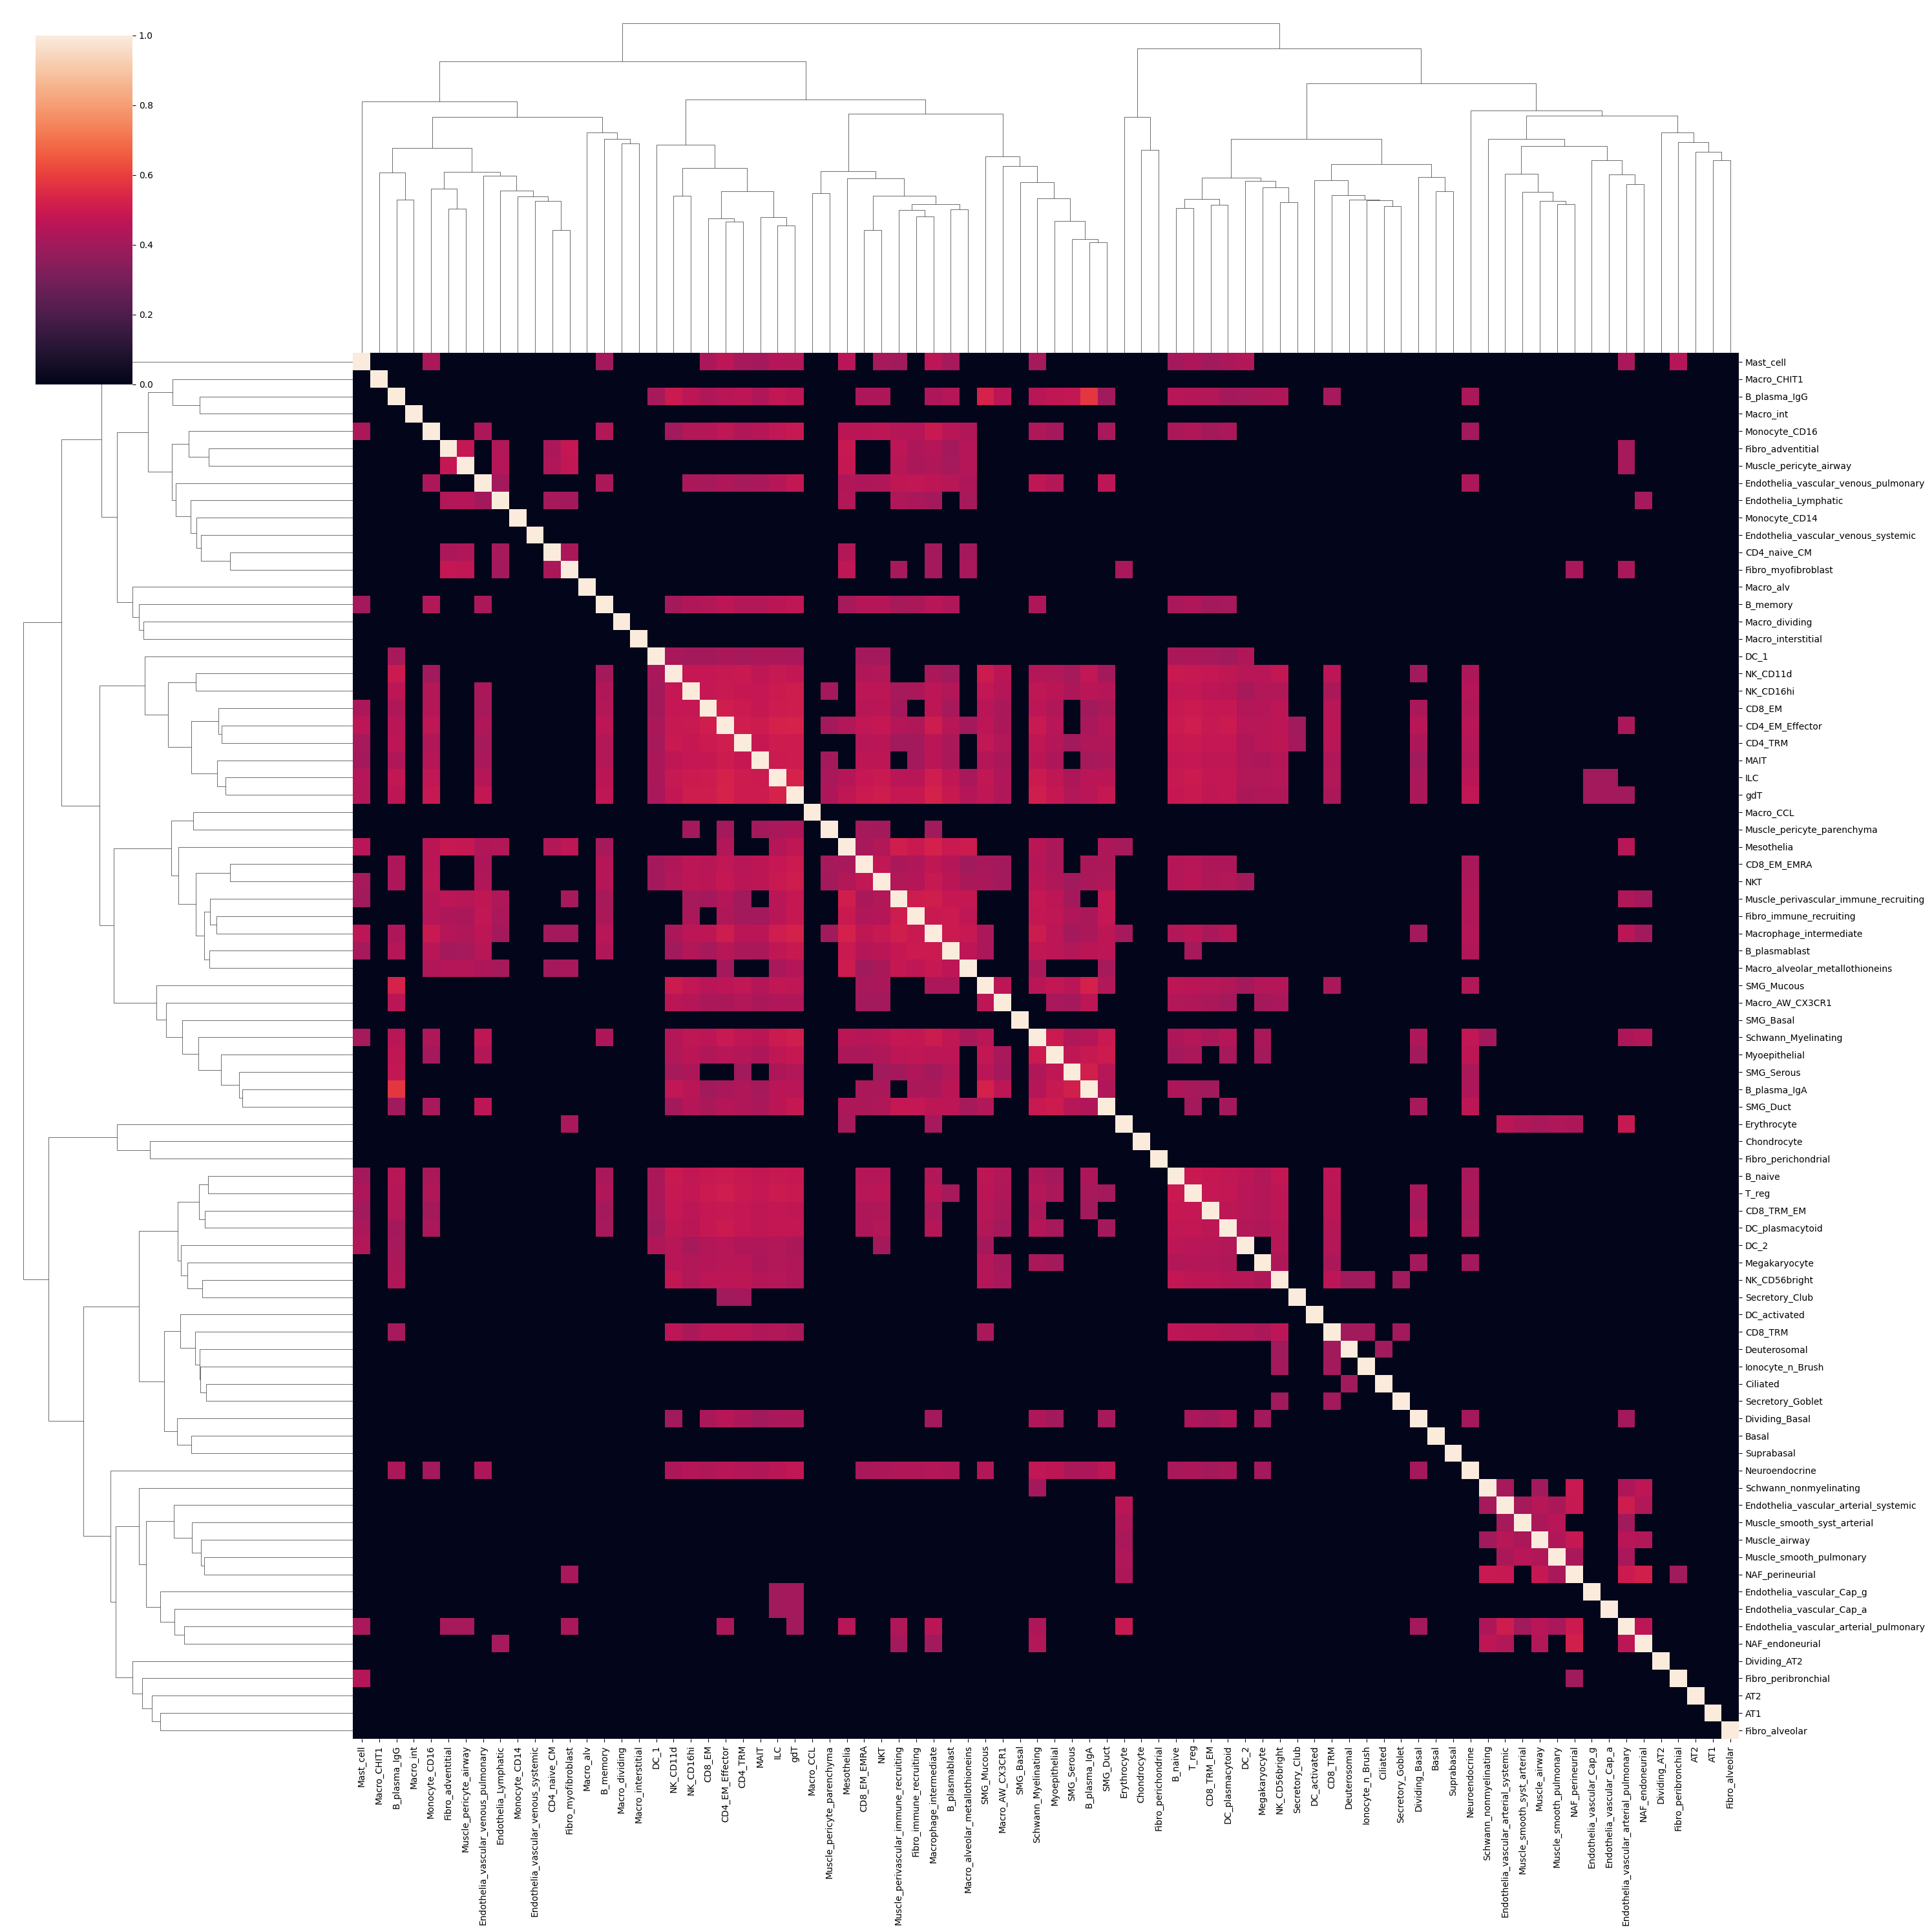

In [90]:
sns.clustermap(normalized_df, figsize=(30, 30), row_linkage=row_linkage, col_linkage=col_linkage)